# Referene

In [1]:
import pandas as pd
import scanpy as sc

adata = sc.read_h5ad("/home/Data_Drive_8TB_2/kykim/potrai/Label_transfer/HPF_sort.h5ad")

In [2]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))
adata.var["hb"] = adata.var_names.str.startswith(("Hba", "Hbb"))
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

In [3]:
adata.n_obs

181653

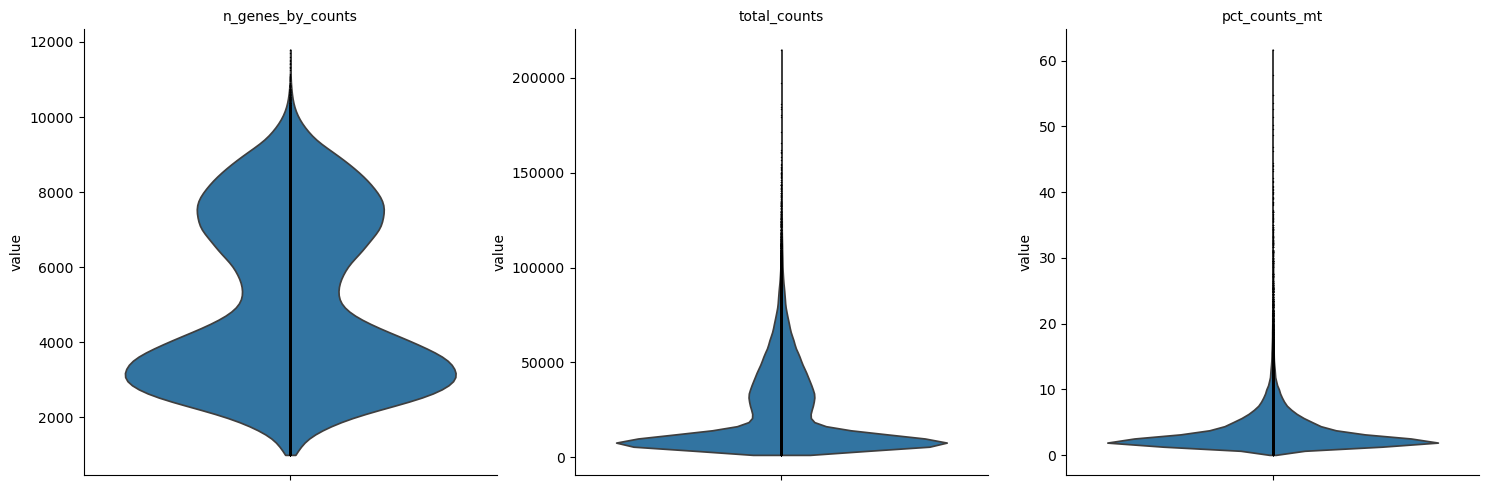

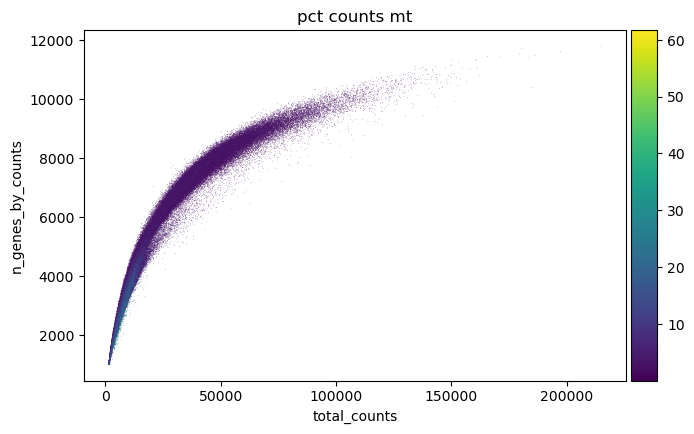

In [4]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.0,
    multi_panel=True,
)
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

Before QC: (181653, 32245)


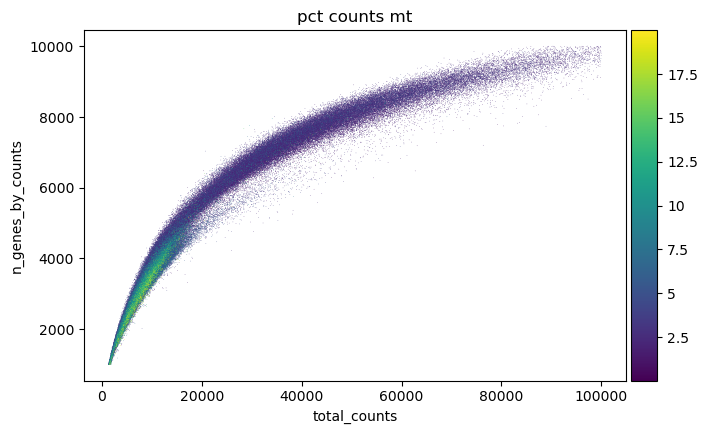

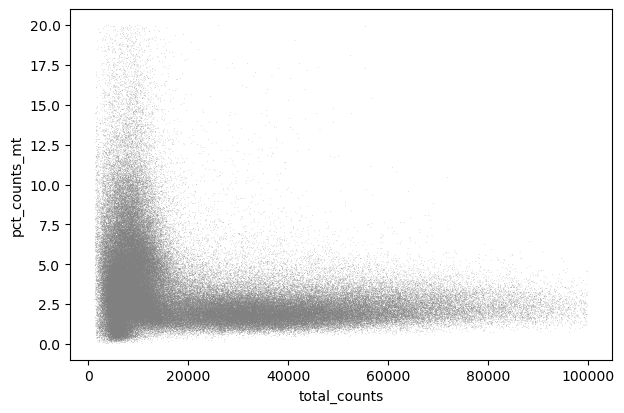

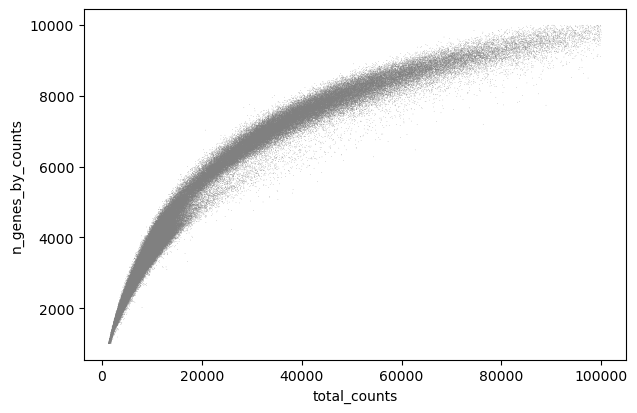

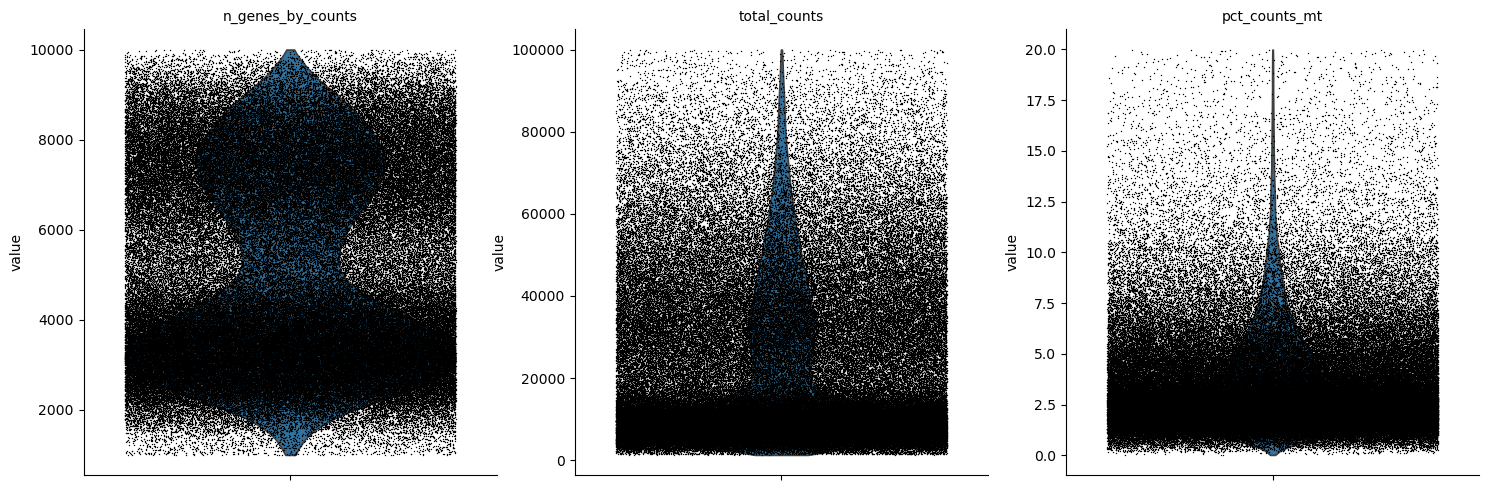

After QC: (179859, 28806)


In [5]:
print("Before QC:", adata.shape)

sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[(adata.obs.n_genes_by_counts <= 10000), :]
adata = adata[adata.obs.pct_counts_mt < 20, :].copy()
adata = adata[(adata.obs.total_counts >= 500) & (adata.obs.total_counts <= 100000), :]

sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)
print("After QC:", adata.shape)

In [8]:
import scrublet
import matplotlib.pyplot as plt
sc.pp.scrublet(adata, batch_key="library_label")
plt.figure(figsize=(6, 4))
plt.hist(adata.obs['doublet_score'], bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Doublet Score')
plt.ylabel('Number of Cells')
plt.title('Distribution of Doublet Scores')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [9]:
adata = adata[adata.obs['predicted_doublet'] == False].copy()
print("After removing doublets:", adata.n_obs)

After removing doublets: 179756


In [10]:
output_path = "/home/Data_Drive_8TB_2/kykim/potrai/scRNA/merge_adata.h5ad"

adata.write(output_path)

In [2]:
import scanpy as sc
file_path = "/home/Data_Drive_8TB_2/kykim/potrai/scRNA/merge_adata.h5ad"
adata = sc.read_h5ad(file_path)

In [3]:
adata.raw = adata.copy()
adata.layers['RNA'] = adata.X

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000)

adata = adata[:, adata.var.highly_variable].copy()

In [4]:
adata = adata[:, adata.var['highly_variable']].copy()

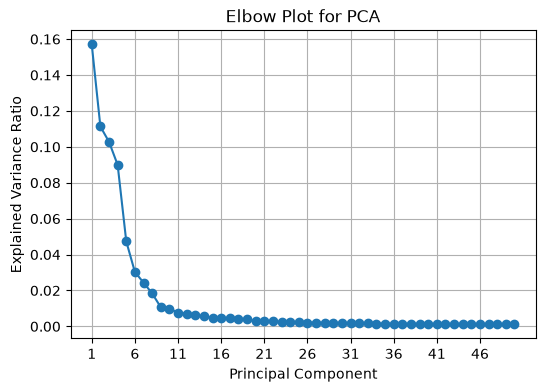

In [5]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

sc.tl.pca(adata)
explained_variance_ratio = adata.uns["pca"]["variance_ratio"]

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker="o", linestyle="-")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Elbow Plot for PCA")
plt.xticks(np.arange(1, len(explained_variance_ratio) + 1, step=5))
plt.grid()
plt.show()

In [5]:
sc.tl.pca(adata, n_comps=16)

In [7]:
import scvi 
from scvi.model import SCVI

scvi.model.SCVI.setup_anndata(adata, layer="RNA", batch_key="library_label")
vae = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")

vae.train(max_epochs=400, early_stopping=True, early_stopping_patience=10)

/home/Data_Drive_8TB/kykim/.conda/envs/scrna/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/Data_Drive_8TB/kykim/.conda/envs/scrna/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[RNA] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/li

Epoch 400/400: 100%|██████████| 400/400 [1:22:20<00:00, 12.85s/it, v_num=1, train_loss=403]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [1:22:20<00:00, 12.35s/it, v_num=1, train_loss=403]


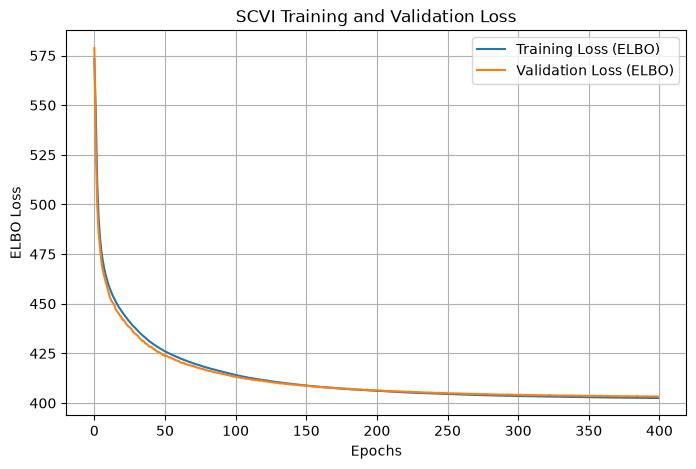

In [8]:
import matplotlib.pyplot as plt

train_loss = vae.history["elbo_train"]
val_loss = vae.history["elbo_validation"]
plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="Training Loss (ELBO)")
plt.plot(val_loss, label="Validation Loss (ELBO)")
plt.xlabel("Epochs")
plt.ylabel("ELBO Loss")
plt.title("SCVI Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

Text(0.5, 1.0, 'scVI')

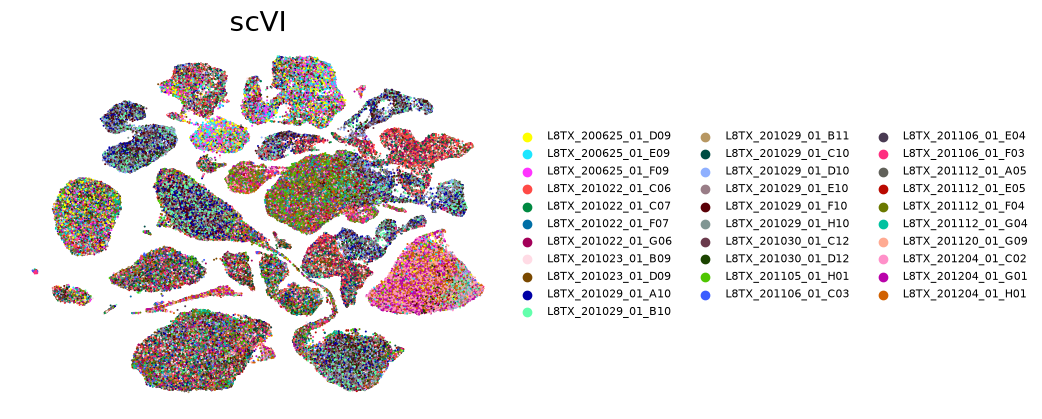

In [9]:
adata.obsm["X_scVI"] = vae.get_latent_representation()
sc.pp.neighbors(adata, use_rep = 'X_scVI')
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color=['library_label'],
    frameon=False,
    size= 8,
    legend_fontsize=8,
    legend_fontoutline=3,
    title="Sample",
    show=False)

plt.title("scVI", fontsize=20)

In [10]:
output_path = "/home/Data_Drive_8TB_2/kykim/potrai/scRNA/after_annotate_adata.h5ad"

adata.write(output_path)

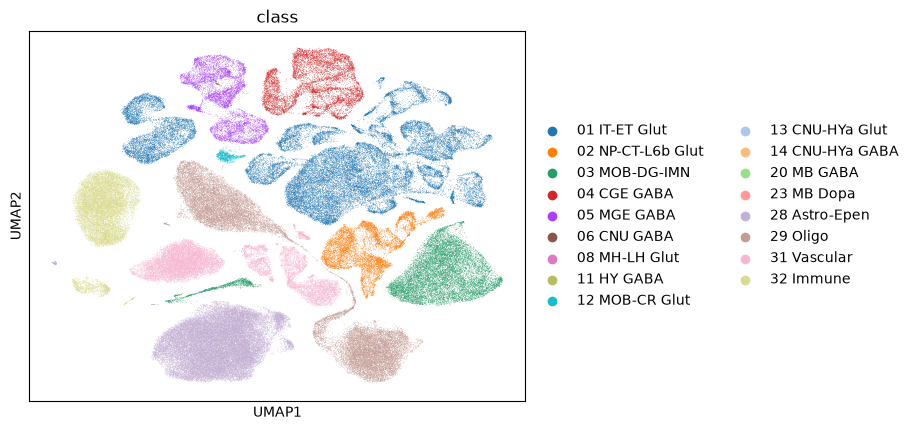

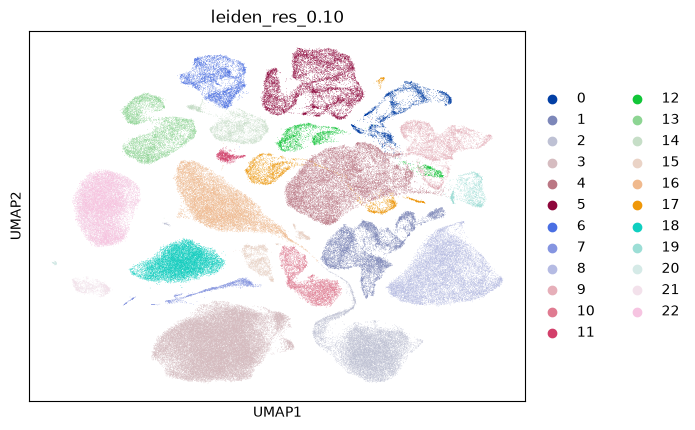

In [31]:
sc.pl.umap(adata, color=["class"])
sc.pl.umap(adata, color=["leiden_res_0.10"])

In [22]:
for res in [0.10, 0.25, 0.50]:
    sc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

In [27]:
adata = adata.raw.to_adata()

In [29]:
adata.raw = adata.copy()

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [32]:
import scanpy as sc
adata.obs['leiden_res_0.10'] = adata.obs['leiden_res_0.10'].astype('category')
sc.tl.rank_genes_groups(adata, groupby='leiden_res_0.10', method='t-test')

top_genes = {}

groups = adata.uns['rank_genes_groups']['names'].dtype.names

for group in groups:
    genes = adata.uns['rank_genes_groups']['names'][group][:20]
    top_genes[group] = genes.tolist()

for cluster, genes in top_genes.items():
    print(f"Cluster {cluster}: {genes}")

/home/Data_Drive_8TB/kykim/.conda/envs/scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/Data_Drive_8TB/kykim/.conda/envs/scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/Data_Drive_8TB/kykim/.conda/envs/scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/Data_Drive_8TB/kykim/.conda/envs/scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/Data_Drive_8TB/kykim/.conda/envs/scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: ov

Cluster 0: ['Snhg11', 'Ldb2', 'Ptprd', 'Tshz3', 'Sorbs2', 'Satb2', 'Slc4a10', 'Kalrn', 'Csmd1', 'Kcnq5', 'Nrgn', 'Lrrtm3', 'Csrnp3', 'Celf2', 'Tmem178b', 'Dock3', 'Nav3', 'Phactr1', 'Psd3', 'Arpp21']
Cluster 1: ['Hs3st4', 'Ptprd', 'Prickle1', 'Efhd2', 'Tbr1', 'Etl4', 'Pbx1', 'Arpp21', 'Grik3', 'Rap1gap2', 'Phactr1', 'Adgra1', 'Tle4', 'Adora1', 'Lmo3', 'Kcnma1', 'Pcdh9', 'Myt1l', 'Stxbp1', 'Fut9']
Cluster 2: ['Lhfpl3', 'Olig1', 'Pdgfra', 'Ptprz1', 'Olig2', 'Cacng4', 'Epn2', 'Cspg4', 'C1ql1', 'Arhgap31', 'Xylt1', 'Vcan', 'Sox10', 'Dscam', 'Matn4', 'Sulf2', 'Sh3d19', 'Sox6', 'Sema3d', 'Megf11']
Cluster 3: ['Plpp3', 'Gja1', 'Atp1a2', 'Gpr37l1', 'Slc1a3', 'S1pr1', 'Ntsr2', 'Fgfr3', 'Htra1', 'Slc1a2', 'Acsbg1', 'Hepacam', 'Bcan', 'Nwd1', 'Pla2g7', 'Slc6a11', 'Gm6145', 'Mfge8', 'Ttyh1', 'Gpc5']
Cluster 4: ['Tmsb4x', 'Fkbp1a', 'Grin2b', 'Calm2', 'Gria2', 'Camkv', 'Celf5', 'Gria1', 'Fam131a', 'Arf1', 'Wasf1', 'Camk2a', 'Calm3', 'Nsg2', 'Tspan13', 'Atp2b1', 'Nrgn', 'Scn8a', 'Snhg11', 'Ptk2b']
Cl

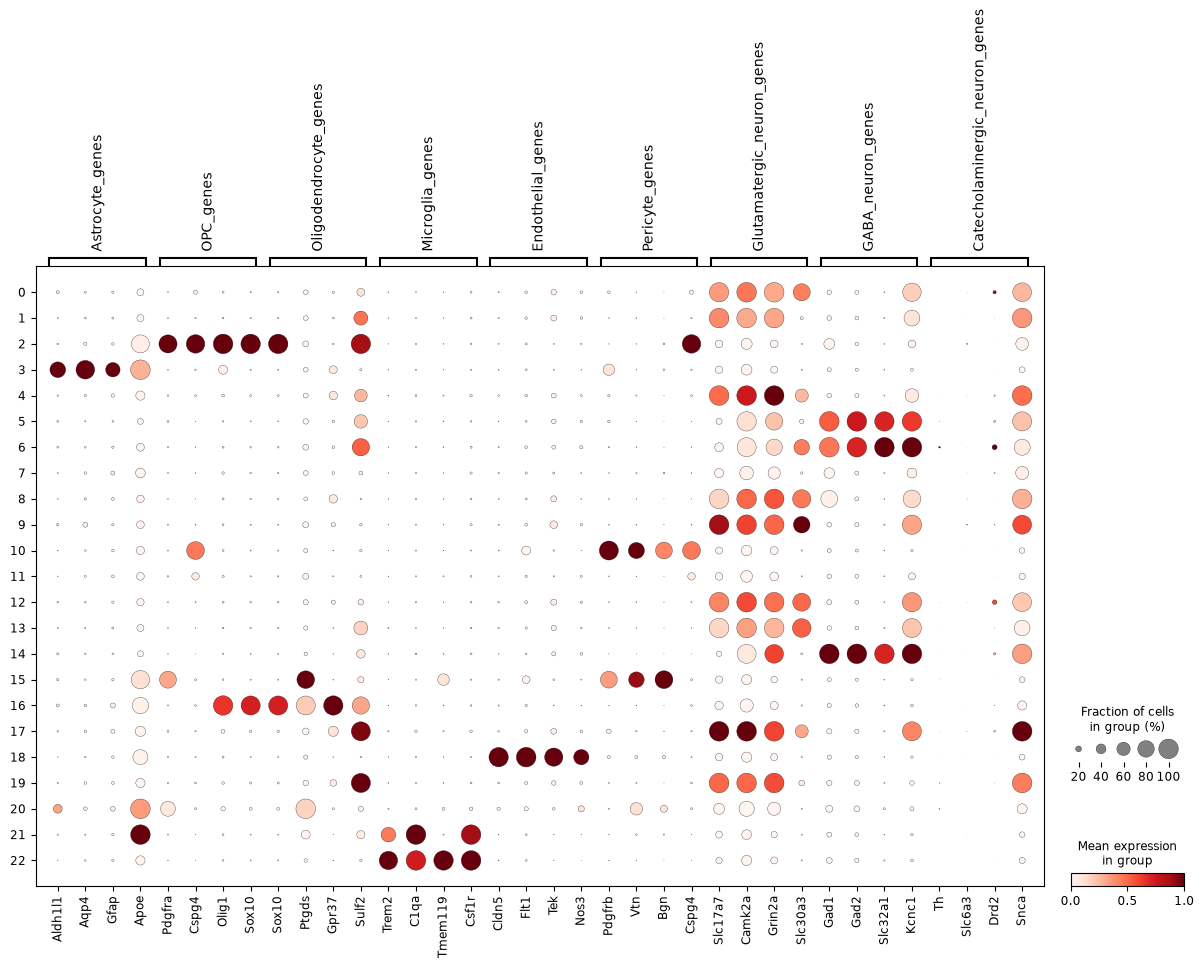

In [30]:
import scanpy as sc

group_markers = {
    "Astrocyte_genes": ['Aldh1l1','Aqp4','Gfap','Apoe'],
    "OPC_genes": ['Pdgfra','Cspg4','Olig1','Sox10'],
    "Oligodendrocyte_genes": ['Sox10','Ptgds','Gpr37','Sulf2'],
    "Microglia_genes": ['Trem2','C1qa','Tmem119','Csf1r'],
    "Endothelial_genes": ['Cldn5','Flt1','Tek','Nos3'],
    "Pericyte_genes": ['Pdgfrb','Vtn','Bgn','Cspg4'],
    "Glutamatergic_neuron_genes": ['Slc17a7','Camk2a','Grin2a','Slc30a3'],
    "GABA_neuron_genes": ['Gad1','Gad2','Slc32a1','Kcnc1'],
    "Catecholaminergic_neuron_genes": ['Th','Slc6a3','Drd2','Snca']}

existing_genes = {cat:[gene for gene in genes if gene in adata.var_names] for cat, genes in group_markers.items()}
existing_genes = {cat:genes for cat, genes in existing_genes.items() if genes}

sc.pl.dotplot(adata, var_names=existing_genes, groupby="leiden_res_0.10", standard_scale="var")

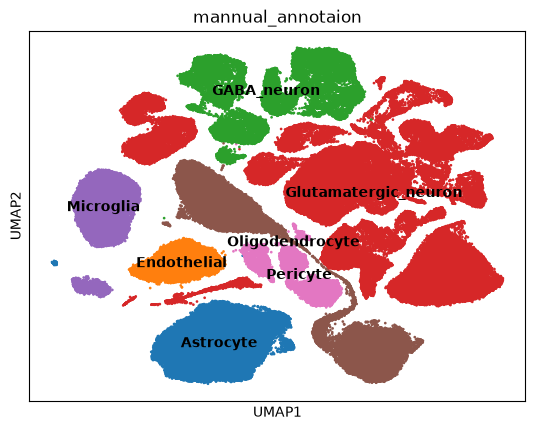

In [37]:
cluster_to_group = {
    0: "Glutamatergic_neuron",      # Satb2, Tshz3, Ptprd
    1: "Glutamatergic_neuron",      # Tbr1, Tle4, Grik3
    2: "Oligodendrocyte",           # Olig1, Olig2, Sox10, Pdgfra
    3: "Astrocyte",                 # Slc1a3, Slc1a2, Gja1, Gpr37l1
    4: "Glutamatergic_neuron",      # Camk2a, Grin2b, Gria1/2
    5: "GABA_neuron",               # Gad1, Slc32a1
    6: "GABA_neuron",               # Gad2, Lhx6, Slc32a1
    7: "Glutamatergic_neuron",      # Dcx, Neurod1, Prox1 (immature DG)
    8: "Glutamatergic_neuron",      # Prox1, Grm1, C1ql3 (DG)
    9: "Glutamatergic_neuron",      # App, Scn2a, Slc12a5
    10: "Pericyte",                 # Pdgfrb, Notch3, Cald1
    11: "GABA_neuron",              # Reln, Ndnf
    12: "Glutamatergic_neuron",     # neuronal markers
    13: "Glutamatergic_neuron",     # Cck+, Tshz2 cortical glut
    14: "GABA_neuron",              # Gad1, Erbb4, Lhx6
    15: "Pericyte",                 # Col1a2, Foxc1, Tgfbr3
    16: "Oligodendrocyte",          # Mbp, Aspa, Myrf, Gpr37
    17: "Glutamatergic_neuron",     # Slc17a7
    18: "Endothelial",              # Flt1, Cldn5, Pecam1
    19: "Glutamatergic_neuron",     # neuronal, excitatory-like
    20: "Astrocyte",                # Kl, Enpp2, Slc12a2 (astro/ependymal)
    21: "Microglia",                # Csf1r, C1qa, Tyrobp
    22: "Microglia"                 # P2ry12, Tmem119, Cx3cr1
}

adata.obs["mannual_annotaion"] = adata.obs["leiden_res_0.10"].astype(int).map(cluster_to_group)

sc.pl.umap(
    adata,
    color='mannual_annotaion',
    legend_loc='on data'
    , s = 15)

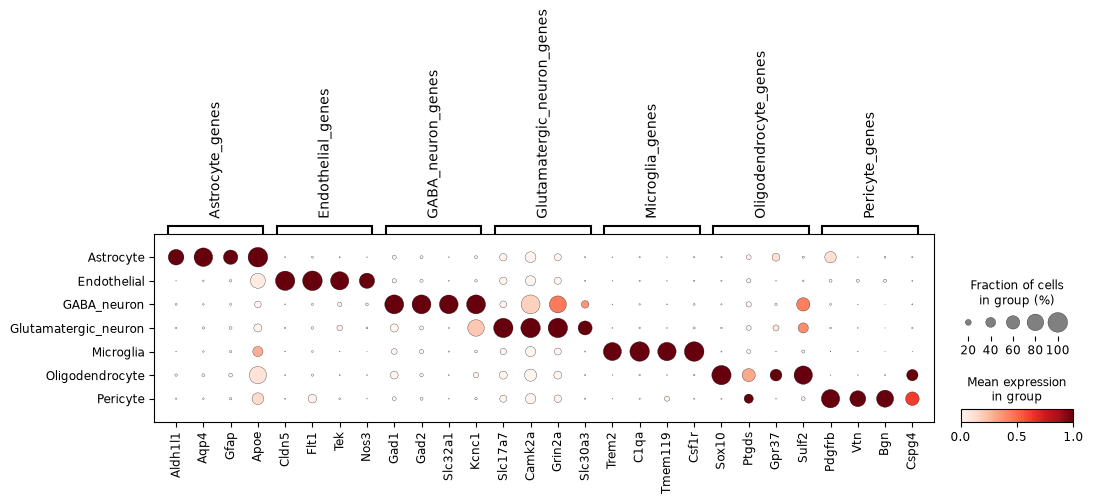

In [39]:
import scanpy as sc

group_markers = {
    "Astrocyte_genes": ['Aldh1l1','Aqp4','Gfap','Apoe'],
    "Endothelial_genes": ['Cldn5','Flt1','Tek','Nos3'],
    "GABA_neuron_genes": ['Gad1','Gad2','Slc32a1','Kcnc1'],
    "Glutamatergic_neuron_genes": ['Slc17a7','Camk2a','Grin2a','Slc30a3'],
    "Microglia_genes": ['Trem2','C1qa','Tmem119','Csf1r'],
    "Oligodendrocyte_genes": ['Sox10','Ptgds','Gpr37','Sulf2'],
    "Pericyte_genes": ['Pdgfrb','Vtn','Bgn','Cspg4']  
}

existing_genes = {cat: [gene for gene in genes if gene in adata.var_names] 
                  for cat, genes in group_markers.items()}
existing_genes = {cat: genes for cat, genes in existing_genes.items() if genes}

sc.pl.dotplot(adata, var_names=existing_genes, groupby="mannual_annotaion", standard_scale="var")

In [40]:
output_path = "/home/Data_Drive_8TB_2/kykim/potrai/scRNA/after_annotate_adata.h5ad"

adata.write(output_path)

In [44]:
adata = sc.read_h5ad("/home/Data_Drive_8TB_2/kykim/potrai/scRNA/after_annotate_adata.h5ad")

# Nichenet

In [132]:
adata = sc.read_h5ad("/home/Data_Drive_8TB_2/kykim/potrai/scRNA/after_annotate_adata.h5ad")

In [133]:
adata = adata.raw.to_adata()

In [82]:
adata = adata[adata.obs["mannual_annotaion"].isin(["Oligodendrocyte", "Microglia"])].copy()

In [134]:
output_path = "/home/Data_Drive_8TB/kykim/6. Alzheimer/Nichnet/all_CCI_adata.h5ad"

adata.write(output_path)

In [195]:
import pandas as pd
from pyvis.network import Network
from IPython.display import IFrame

df = pd.read_csv("/home/Data_Drive_8TB/kykim/6. Alzheimer/Nichnet/active_signaling_network_together.csv")

net = Network(
    height="900px",
    width="50%",
    directed=True,
    bgcolor="white",
    font_color="black",
    notebook=False
)

edge_colors = {
    "signaling": "#4E79A7",
    "regulatory": "#F28E2B"}

nodes = set()

for _, row in df.iterrows():

    for node in [row["from"], row["to"]]:

        if node in nodes:
            continue

        if node == "Ntm":
            color = "#00AA00"

        elif node in ["Trem2", "Apoe"]:
            color = "#D62728"

        else:
            color = "#BDBDBD"

        net.add_node(
            node,
            label=node,
            color=color,
            shape="dot",
            size=20
        )

        nodes.add(node)
    
    net.add_edge(
        row["from"],
        row["to"],
        color=edge_colors.get(row["layer"], "#999999"),
        width=max(float(row["weight"])*0.5, 1),
    #    value=row["weight"],
        arrows="to"
    )

net.toggle_physics(True)

net.set_options("""
var options = {
  "interaction": {
    "dragNodes": true,
    "dragView": true,
    "zoomView": true
  },
  "physics": {
    "enabled": false
  }
}
""")

outfile = "/home/Data_Drive_8TB/kykim/6. Alzheimer/Nichnet/network.html"

net.save_graph(outfile)

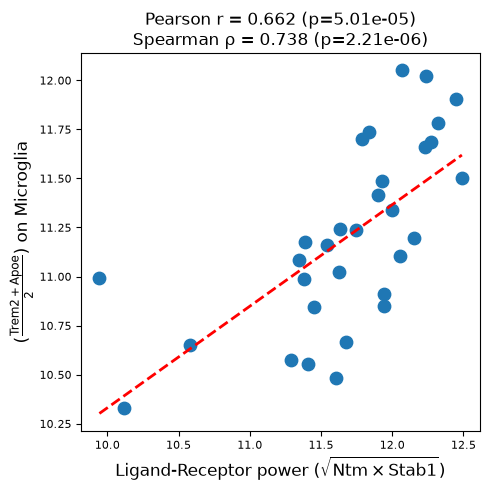

In [222]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

oligo = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/6. Alzheimer/DESeq2/Oligodendrocyte_bulk_rna_vsd_preprocess.csv",
    index_col=0
)

micro = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/6. Alzheimer/DESeq2/Microglia_bulk_rna_vsd_preprocess.csv",
    index_col=0
)

x = np.sqrt(oligo.loc["Ntm"] * micro.loc["Stab1"])
y = (micro.loc["Trem2"] + micro.loc["Apoe"]) / 2

df = pd.DataFrame({
    "Ligand_Receptor_power": x,
    "Trem2_Apoe_mean_expression": y
}).dropna()

pearson_r, pearson_p = pearsonr(
    df["Ligand_Receptor_power"],
    df["Trem2_Apoe_mean_expression"]
)

spearman_rho, spearman_p = spearmanr(
    df["Ligand_Receptor_power"],
    df["Trem2_Apoe_mean_expression"]
)

plt.figure(figsize=(5,5))

plt.scatter(
    df["Ligand_Receptor_power"],
    df["Trem2_Apoe_mean_expression"],
    s=80
)

coef = np.polyfit(
    df["Ligand_Receptor_power"],
    df["Trem2_Apoe_mean_expression"],
    1
)

x_line = np.linspace(
    df["Ligand_Receptor_power"].min(),
    df["Ligand_Receptor_power"].max(),
    100
)

y_line = coef[0] * x_line + coef[1]

plt.plot(
    x_line,
    y_line,
    linestyle="--",
    color="red",
    linewidth=2
)

plt.xlabel(
    r"Ligand-Receptor power ($\sqrt{\mathrm{Ntm} \times \mathrm{Stab1}}$)",
    fontsize=12
)

plt.ylabel(
    r"($\frac{\mathrm{Trem2}+\mathrm{Apoe}}{2}$) on Microglia",
    fontsize=12
)
plt.tick_params(
    axis="both",
    labelsize=8
)

plt.title(
    f"Pearson r = {pearson_r:.3f} (p={pearson_p:.2e})\n"
    f"Spearman ρ = {spearman_rho:.3f} (p={spearman_p:.2e})",
    fontsize=12)

plt.tight_layout()
plt.show()

In [205]:
adata = sc.read_h5ad("/home/Data_Drive_8TB_2/kykim/potrai/scRNA/after_annotate_adata.h5ad")
adata = adata[adata.obs["mannual_annotaion"].isin(["Oligodendrocyte", "Microglia"])].copy()

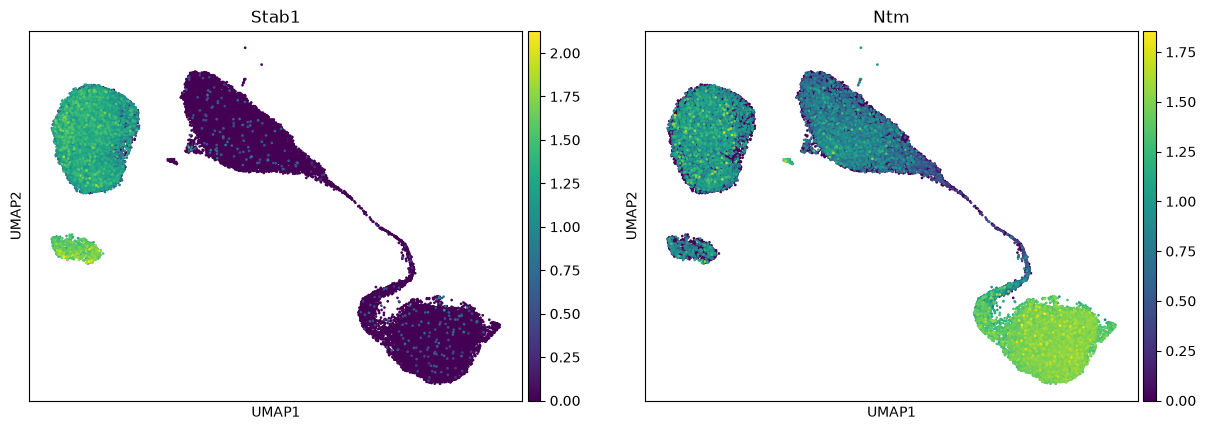

In [218]:
sc.pl.umap(
    adata,
    color=['Stab1','Ntm'],
    use_raw=False,
    legend_loc='on data',
    s=15
)

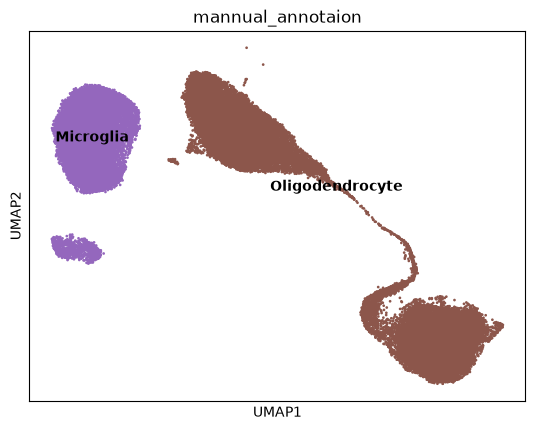

In [219]:
sc.pl.umap(
    adata,
    color=['mannual_annotaion'],
    use_raw=False,
    legend_loc='on data',
    s=15
)

In [224]:
adata.obs

,cell_barcode,library_label,anatomical_division_label,cluster_alias,library_method,region_of_interest_acronym,donor_label,donor_genotype,donor_sex,dataset_label,matrix_label,x,y,neurotransmitter,division,class,subclass,supertype,cluster,neurotransmitter_color,division_color,class_color,subclass_color,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_genes,doublet_score,predicted_doublet,_scvi_batch,_scvi_labels,leiden_res_0.10,leiden_res_0.25,leiden_res_0.50,mannual_annotaion
cell_label,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AGGGTGATCTGGCCTT-412_B07,AGGGTGATCTGGCCTT,L8TX_201030_01_D12,HPF,108,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550849,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,M,WMB-10Xv3,WMB-10Xv3-HPF,-4.230337,4.216374,Glut,1 Pallium glutamatergic,01 IT-ET Glut,004 L6 IT CTX Glut,0014 L6 IT CTX Glut_2,0039 L6 IT CTX Glut_2,#2B93DF,#4D58FF,#f74294,#925C99,#2E5266,#CC211F,15,#CCB05C,4112,8.321908,10043.0,9.214730,13.561685,20.043812,28.845962,44.717714,220.0,5.398163,2.190581,826.0,6.717805,8.224634,0.0,0.0,0.0,4111,0.034072,False,18,0,2,2,3,Oligodendrocyte
AACAAAGAGCAACTCT-420_B06,AACAAAGAGCAACTCT,L8TX_201106_01_C03,HPF,2405,10Xv3,HIP,Snap25-IRES2-Cre;Ai14-551017,Ai14(RCL-tdT)/wt,M,WMB-10Xv3,WMB-10Xv3-HPF,-1.060334,7.233149,Dopa,3 PAL-sAMY-TH-HY-MB-HB neuronal,23 MB Dopa,250 SNc-VTA-RAmb Foxa1 Dopa,0937 SNc-VTA-RAmb Foxa1 Dopa_3,4871 SNc-VTA-RAmb Foxa1 Dopa_3,#fcf04b,#9F3DCC,#6BB8D6,#992E62,#993217,#0F0099,14,#FF8F00,2289,7.736307,4271.0,8.359838,23.366893,29.735425,38.351674,54.577382,551.0,6.313548,12.900961,138.0,4.934474,3.231093,0.0,0.0,0.0,2288,0.095238,False,20,0,16,19,21,Oligodendrocyte
GTCAAACAGAATTCAG-398_D01,GTCAAACAGAATTCAG,L8TX_201022_01_C06,HPF,248,10Xv3,ENT,Snap25-IRES2-Cre;Ai14-546813,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,M,WMB-10Xv3,WMB-10Xv3-HPF,-1.996985,-8.473018,Glut,1 Pallium glutamatergic,01 IT-ET Glut,011 L2 IT ENT-po Glut,0050 L2 IT ENT-po Glut_1,0187 L2 IT ENT-po Glut_1,#2B93DF,#4D58FF,#f74294,#2E6663,#5A2E99,#FF73E6,16,#99922E,5474,8.607948,19042.0,9.854455,22.166789,27.901481,35.132864,48.440290,1923.0,7.562161,10.098729,442.0,6.093570,2.321185,0.0,0.0,0.0,5474,0.395225,False,3,0,16,19,21,Oligodendrocyte
CTCTCAGCAACAGATA-410_A05,CTCTCAGCAACAGATA,L8TX_201029_01_A10,HPF,26,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,F,WMB-10Xv3,WMB-10Xv3-HPF,-9.396754,5.718983,Glut,1 Pallium glutamatergic,02 NP-CT-L6b Glut,026 L6b/CT ENT Glut,0104 L6b/CT ENT Glut_3,0416 L6b/CT ENT Glut_3,#2B93DF,#4D58FF,#61e2a4,#CC0098,#B4CC5C,#88CC5C,15,#CCB05C,4792,8.474912,13728.0,9.527266,16.353438,22.661713,31.075175,46.015443,264.0,5.579730,1.923077,427.0,6.059123,3.110431,0.0,0.0,0.0,4791,0.095238,False,9,0,16,19,21,Oligodendrocyte
CCCTCAAGTCTCAAGT-410_A05,CCCTCAAGTCTCAAGT,L8TX_201029_01_A10,HPF,34,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,F,WMB-10Xv3,WMB-10Xv3-HPF,-8.017551,9.788520,Glut,1 Pallium glutamatergic,02 NP-CT-L6b Glut,027 L6b CTX Glut,0108 L6b CTX Glut_3,0429 L6b CTX Glut_3,#2B93DF,#4D58FF,#61e2a4,#9EFF99,#5C9986,#994582,15,#CCB05C,3324,8.109225,7432.0,8.913685,18.312702,25.215285,34.324543,49.919268,231.0,5.446737,3.108181,216.0,5.379897,2.906351,0.0,0.0,0.0,3323,0.307292,False,9,0,2,25,29,Oligodendrocyte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGTCAGCAATC-410_B05,TTTGTTGTCAGCAATC,L8TX_201030_01_C12,HPF,5283,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,F,WMB-10Xv3,WMB-10Xv3-HPF,-11.148434,13.350853,NaN,7 Immune,32 Immune,302 

# DESeq2

In [157]:
import scanpy as sc
import pandas as pd
import scipy.sparse as sp

adata = sc.read_h5ad("/home/Data_Drive_8TB_2/kykim/potrai/scRNA/after_annotate_adata.h5ad")

adata = adata.raw.to_adata()

celltypes = ["Microglia"]

ad = adata[adata.obs["mannual_annotaion"].isin(celltypes)].copy()

X = ad.layers["counts"] if "counts" in ad.layers else ad.X
if sp.issparse(X):
    X = X.toarray()

counts = pd.DataFrame(
    X,
    index=ad.obs["library_label"],
    columns=ad.var_names
)

pseudobulk = counts.groupby(level=0).sum().T

pseudobulk.to_csv("/home/Data_Drive_8TB/kykim/6. Alzheimer/DESeq2/pseudobulk_Microglia.csv")

/tmp/ipykernel_141683/2473543298.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pseudobulk = counts.groupby(level=0).sum().T


In [158]:
import scanpy as sc
import pandas as pd
import scipy.sparse as sp

adata = sc.read_h5ad("/home/Data_Drive_8TB_2/kykim/potrai/scRNA/after_annotate_adata.h5ad")

adata = adata.raw.to_adata()

celltypes = ["Microglia", "Oligodendrocyte"]

ad = adata[adata.obs["mannual_annotaion"].isin(celltypes)].copy()

X = ad.layers["counts"] if "counts" in ad.layers else ad.X
if sp.issparse(X):
    X = X.toarray()

counts = pd.DataFrame(
    X,
    index=ad.obs["library_label"],
    columns=ad.var_names
)

pseudobulk = counts.groupby(level=0).sum().T

pseudobulk.to_csv("/home/Data_Drive_8TB/kykim/6. Alzheimer/DESeq2/pseudobulk_Oligodendrocyte.csv")

/tmp/ipykernel_141683/2974107543.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pseudobulk = counts.groupby(level=0).sum().T


In [154]:
meta = (
    ad.obs[["library_label", "region_of_interest_acronym","donor_genotype","donor_sex"]]
    .drop_duplicates("library_label")
    .set_index("library_label")
)

meta.to_csv("/home/Data_Drive_8TB/kykim/6. Alzheimer/DESeq2/sample_id_age_group.csv")